# Análise exploratória dos dados telefônicos de Campinas

Este notebook faz uma análise exploratória simples da base `Campinas.parquet`.

O foco aqui é entender a estrutura dos dados, o comportamento dos emissores, o volume de chamadas, a diversidade de contatos, a distância residencial já presente no parquet e preparar uma tabela de arestas emissor-receptor. Nenhuma etapa usa o arquivo `residencias.csv`.

## Perguntas desta EDA

- Quantos emissores existem na base?
- As colunas do parquet estão consistentes?
- Como se distribuem o total de chamadas e a quantidade de receptores por emissor?
- Poucos emissores concentram muitas chamadas?
- Como transformar as listas internas em uma tabela simples de arestas emissor-receptor?
- As chamadas estão concentradas em poucos pares emissor-receptor?
- Como se distribuem as distâncias residenciais entre emissores e receptores?
- Existe alguma relação aparente entre distância residencial, quantidade de chamadas e duração?
- Os emissores tendem a falar com muitos contatos ou concentrar chamadas em poucos contatos?

## Imports e caminhos

In [1]:
from pathlib import Path
import sys

# Evita extensões opcionais que podem causar conflito em alguns ambientes.
sys.modules['numexpr'] = None
sys.modules['bottleneck'] = None

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('./dados')
CAMPINAS_PATH = DATA_DIR / 'Campinas.parquet'
RESIDENCIAS_PATH = DATA_DIR / 'residencias.csv'

CAMPINAS_PATH.exists()

True

## Dicionário dos dados usados

| Coluna | Como será usada aqui |
|---|---|
| `id_emisor` | Identificador anonimizado do usuário emissor. |
| `total_calls_make` | Total de chamadas feitas pelo emissor. |
| `unique_receivers` | Quantidade de receptores distintos chamados pelo emissor. |
| `IDs_receivers_corr` | Lista de receptores associados ao emissor. |
| `q_calls_corr` | Lista com a quantidade de chamadas para cada receptor. |
| `residence_distance_km_corr` | Lista com a distância residencial, em km, entre emissor e receptor. |
| `calls_duration_total_corr` | Lista com a duração total das chamadas para cada receptor. |

## Carregamento da base

Antes de carregar tudo, olhamos rapidamente o schema do parquet. Depois lemos a base em memória, porque o arquivo de Campinas é pequeno para uma EDA local.

In [2]:
parquet_file = pq.ParquetFile(CAMPINAS_PATH)
print(parquet_file.schema)
print(f'Linhas: {parquet_file.metadata.num_rows:,}')
print(f'Grupos de linhas: {parquet_file.metadata.num_row_groups}')

required group field_id=-1 schema {
  optional binary field_id=-1 city_residences (String);
  optional binary field_id=-1 id_emisor (String);
  optional int64 field_id=-1 total_calls_make;
  optional int64 field_id=-1 unique_receivers;
  optional group field_id=-1 IDs_receivers_corr (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 q_calls_corr (List) {
    repeated group field_id=-1 list {
      optional int64 field_id=-1 element;
    }
  }
  optional group field_id=-1 residence_distance_km_corr (List) {
    repeated group field_id=-1 list {
      optional double field_id=-1 element;
    }
  }
  optional group field_id=-1 calls_duration_total_corr (List) {
    repeated group field_id=-1 list {
      optional double field_id=-1 element;
    }
  }
}

Linhas: 25,273
Grupos de linhas: 1


In [3]:
campinas = parquet_file.read().to_pandas()
campinas.head()

,city_residences,id_emisor,total_calls_make,unique_receivers,IDs_receivers_corr,q_calls_corr,residence_distance_km_corr,calls_duration_total_corr
0,Campinas,40E078FF843A5C75DCBB0C4F7A16F631,3,1,[F2EB3D83BD88218C80006292B341539B],[3],[10.007532982573254],[2.6999999999999997]
1,Campinas,E251FECC98A8A1A6A669F4A96E5E83FD,18,1,[37EDC910464F29BEB60588CE5A3CE0D4],[18],[5.480984663942183],[139.54]
2,Campinas,89DCFE25604A02CB8B80725D4AA896C6,1,1,[8DBF6A18EEB743B322CB639529E90198],[1],[0.0],[2.45]
3,Campinas,1DEF0A07C69528F86FC5F9540511BD10,32,1,[605AF7D72A6CE93EA7BB0BDB21ACE525],[32],[0.0],[45.98]
4,Campinas,9749A47A3F466E787C1262E04FFDA8A1,4,1,[9F34A780F9A3F3EA69867ECFCE914735],[4],[9.379524846356823],[1.55]


## Qualidade e consistência

Esta etapa verifica se há nulos, quantos valores únicos existem por coluna e se as listas internas batem com os totais declarados. Isso é importante porque cada posição das listas representa o mesmo par emissor-receptor.

In [4]:
resumo_colunas = pd.DataFrame({
    'tipo': campinas.dtypes.astype(str),
    'nulos': campinas.isna().sum(),
    'pct_nulos': campinas.isna().mean(),
    'n_unicos': [campinas[col].astype(str).nunique() for col in campinas.columns],
})
resumo_colunas

,tipo,nulos,pct_nulos,n_unicos
city_residences,str,0,0.0,1
id_emisor,str,0,0.0,25273
total_calls_make,int64,0,0.0,355
unique_receivers,int64,0,0.0,36
IDs_receivers_corr,object,0,0.0,23942
q_calls_corr,object,0,0.0,7341
residence_distance_km_corr,object,0,0.0,15725
calls_duration_total_corr,object,0,0.0,18191


In [5]:
list_cols = ['IDs_receivers_corr', 'q_calls_corr', 'residence_distance_km_corr', 'calls_duration_total_corr']

for col in list_cols:
    campinas[f'n_{col}'] = campinas[col].apply(len)

campinas['soma_q_calls_corr'] = campinas['q_calls_corr'].apply(sum)

checks = pd.DataFrame({
    'linhas': [len(campinas)],
    'emissores_unicos': [campinas['id_emisor'].nunique()],
    'emissores_duplicados': [campinas['id_emisor'].duplicated().sum()],
    'unique_receivers_confere': [(campinas['unique_receivers'] == campinas['n_IDs_receivers_corr']).all()],
    'listas_mesmo_tamanho': [(campinas[[f'n_{c}' for c in list_cols]].nunique(axis=1) == 1).all()],
    'total_calls_confere': [(campinas['total_calls_make'] == campinas['soma_q_calls_corr']).all()],
})
checks

,linhas,emissores_unicos,emissores_duplicados,unique_receivers_confere,listas_mesmo_tamanho,total_calls_confere
0,25273,25273,0,True,True,True


In [6]:
inconsistencias = campinas.loc[
    (campinas['unique_receivers'] != campinas['n_IDs_receivers_corr']) |
    (campinas[[f'n_{c}' for c in list_cols]].nunique(axis=1) != 1) |
    (campinas['total_calls_make'] != campinas['soma_q_calls_corr']),
    ['id_emisor', 'total_calls_make', 'soma_q_calls_corr', 'unique_receivers'] + [f'n_{c}' for c in list_cols]
]

inconsistencias.head()

,id_emisor,total_calls_make,soma_q_calls_corr,unique_receivers,n_IDs_receivers_corr,n_q_calls_corr,n_residence_distance_km_corr,n_calls_duration_total_corr


## Visão geral dos emissores

Cada linha representa um emissor. Aqui criamos uma métrica simples, `chamadas_por_receptor`, que ajuda a diferenciar quem liga para muitos contatos de quem concentra chamadas em poucos contatos.

In [7]:
campinas['chamadas_por_receptor'] = campinas['total_calls_make'] / campinas['unique_receivers'].replace(0, np.nan)

resumo_geral = pd.DataFrame({
    'emissores': [campinas['id_emisor'].nunique()],
    'chamadas_total': [campinas['total_calls_make'].sum()],
    'receptores_distintos_somados': [campinas['unique_receivers'].sum()],
    'media_chamadas_por_emissor': [campinas['total_calls_make'].mean()],
    'mediana_chamadas_por_emissor': [campinas['total_calls_make'].median()],
    'media_receptores_por_emissor': [campinas['unique_receivers'].mean()],
    'mediana_receptores_por_emissor': [campinas['unique_receivers'].median()],
})
resumo_geral

,emissores,chamadas_total,receptores_distintos_somados,media_chamadas_por_emissor,mediana_chamadas_por_emissor,media_receptores_por_emissor,mediana_receptores_por_emissor
0,25273,674549,56139,26.6905,12.0,2.221303,2.0


In [8]:
emissor_cols = ['total_calls_make', 'unique_receivers', 'chamadas_por_receptor']
campinas[emissor_cols].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
total_calls_make,25273.0,26.690500,46.986240,1.0,1.0,1.0,3.0,12.0,32.0,66.0,97.0,199.56,1876.0
unique_receivers,25273.0,2.221303,1.950573,1.0,1.0,1.0,1.0,2.0,3.0,4.0,5.0,9.00,57.0
chamadas_por_receptor,25273.0,12.918164,21.519446,1.0,1.0,1.0,2.0,6.0,15.0,31.5,48.0,100.64,619.0


## Distribuições dos emissores

O primeiro gráfico mostra a distribuição original do total de chamadas. O segundo usa `log1p`, isto é, `log(1 + x)`, para enxergar melhor a cauda da distribuição quando há poucos usuários muito ativos.

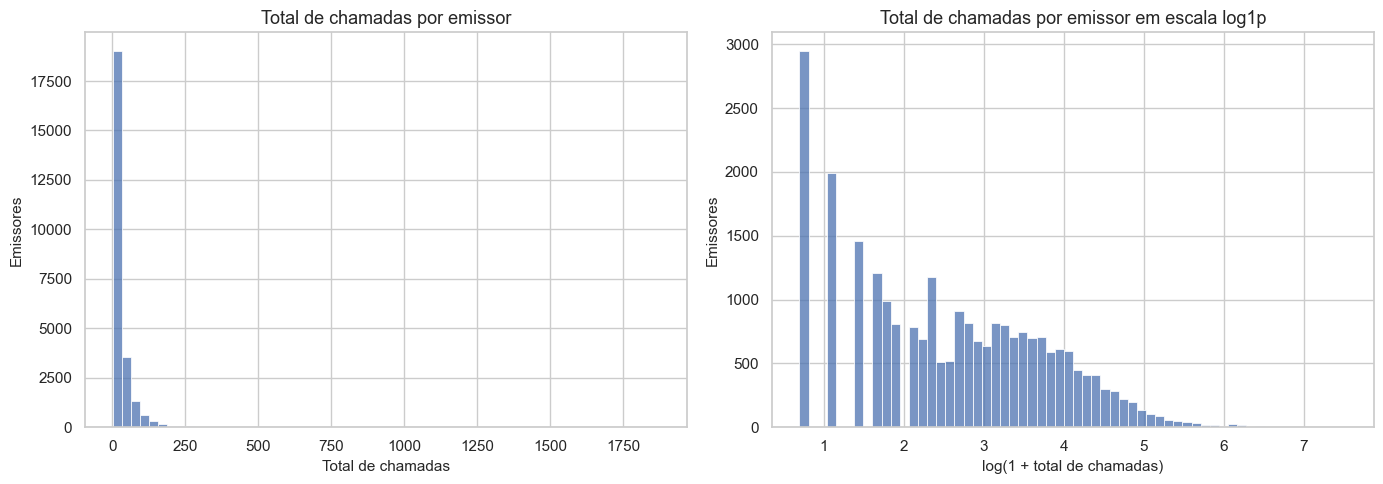

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=campinas, x='total_calls_make', bins=60, ax=axes[0])
axes[0].set_title('Total de chamadas por emissor')
axes[0].set_xlabel('Total de chamadas')
axes[0].set_ylabel('Emissores')

sns.histplot(x=np.log1p(campinas['total_calls_make']), bins=60, ax=axes[1])
axes[1].set_title('Total de chamadas por emissor em escala log1p')
axes[1].set_xlabel('log(1 + total de chamadas)')
axes[1].set_ylabel('Emissores')

plt.tight_layout()
plt.show()

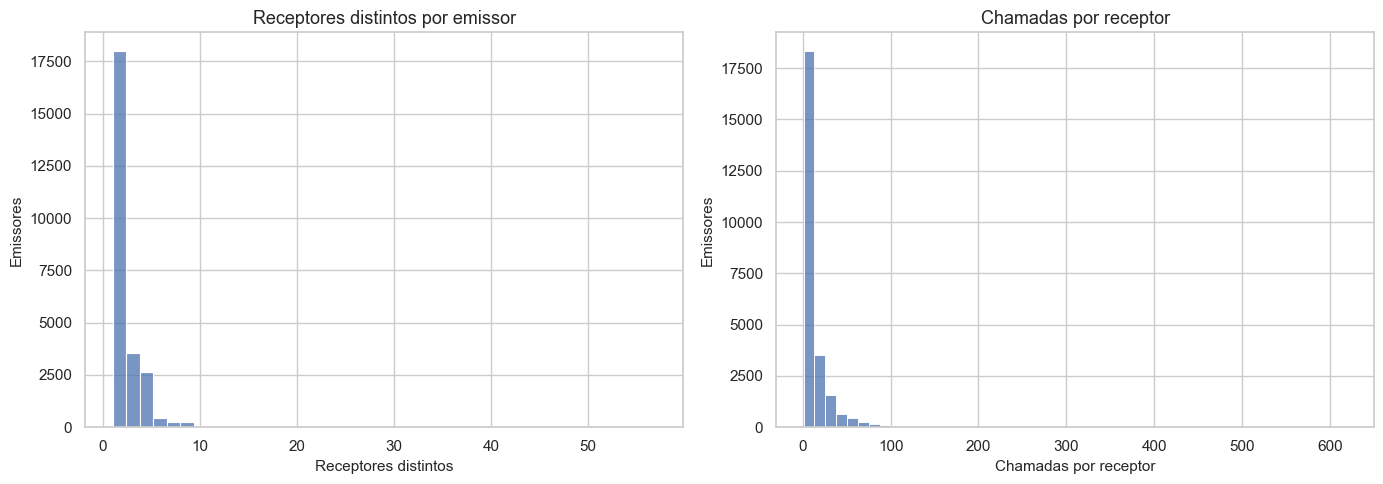

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=campinas, x='unique_receivers', bins=40, ax=axes[0])
axes[0].set_title('Receptores distintos por emissor')
axes[0].set_xlabel('Receptores distintos')
axes[0].set_ylabel('Emissores')

sns.histplot(data=campinas, x='chamadas_por_receptor', bins=50, ax=axes[1])
axes[1].set_title('Chamadas por receptor')
axes[1].set_xlabel('Chamadas por receptor')
axes[1].set_ylabel('Emissores')

plt.tight_layout()
plt.show()

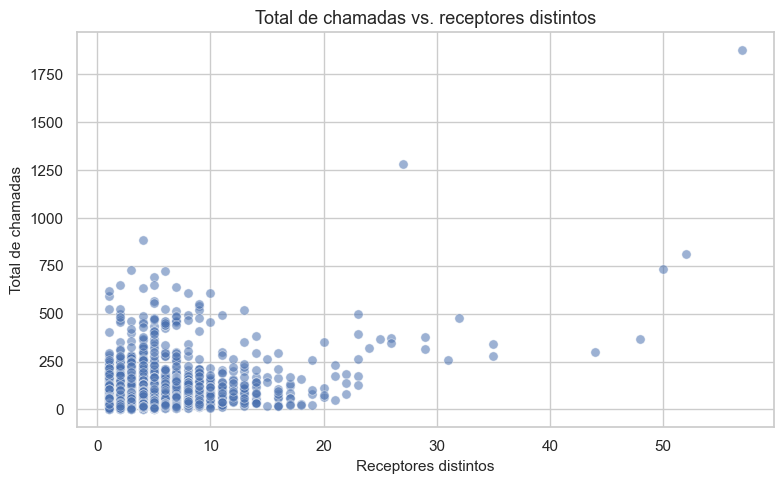

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=campinas,
    x='unique_receivers',
    y='total_calls_make',
    alpha=0.55,
    s=45,
)
plt.title('Total de chamadas vs. receptores distintos')
plt.xlabel('Receptores distintos')
plt.ylabel('Total de chamadas')
plt.tight_layout()
plt.show()

## Emissores mais ativos

A tabela abaixo mostra os emissores com maior volume de chamadas. Ela ajuda a identificar se existem observações muito acima do restante da base.

In [12]:
top_emissores = campinas[[
    'id_emisor',
    'total_calls_make',
    'unique_receivers',
    'chamadas_por_receptor',
]].sort_values('total_calls_make', ascending=False)

top_emissores.head(15)

,id_emisor,total_calls_make,unique_receivers,chamadas_por_receptor
15766,E28A08C70F470859BAD69000FEA2BC04,1876,57,32.912281
23203,E7AF3ECA9BBCB7F2A213A9ACF7098C69,1281,27,47.444444
18693,62C705AD6A69DA254A33F3A9B9952CE6,884,4,221.000000
4341,AC09CBBB8015C7550472AAB74BC413EA,814,52,15.653846
21057,785588489597E9356E54E6EAFE08BBE6,732,50,14.640000
24081,46D13D45048C8F41C9A6F1FF1A4DF9E3,726,3,242.000000
10806,64905D2B86772F6F31B008990575048E,721,6,120.166667
774,679C626660F0E5E3875FD2C339656038,694,5,138.800000
14719,CD2236EC3D5CB1FB25A84482E0769FEA,652,2,326.000000
2327,74B583B7515A76B33062DDF12989F3CD,650,5,130.000000


## Pareto do volume de chamadas

O Pareto mede concentração. Aqui a pergunta é: qual percentual das chamadas vem dos emissores mais ativos? Se poucos emissores explicam grande parte das chamadas, a curva sobe rapidamente.

In [13]:
pareto = campinas[['id_emisor', 'total_calls_make', 'unique_receivers']].sort_values('total_calls_make', ascending=False).reset_index(drop=True)
pareto['rank'] = np.arange(1, len(pareto) + 1)
pareto['pct_emissores'] = pareto['rank'] / len(pareto)
pareto['pct_chamadas_acum'] = pareto['total_calls_make'].cumsum() / pareto['total_calls_make'].sum()
pareto.head(10)

,id_emisor,total_calls_make,unique_receivers,rank,pct_emissores,pct_chamadas_acum
0,E28A08C70F470859BAD69000FEA2BC04,1876,57,1,0.000040,0.002781
1,E7AF3ECA9BBCB7F2A213A9ACF7098C69,1281,27,2,0.000079,0.004680
2,62C705AD6A69DA254A33F3A9B9952CE6,884,4,3,0.000119,0.005991
3,AC09CBBB8015C7550472AAB74BC413EA,814,52,4,0.000158,0.007197
4,785588489597E9356E54E6EAFE08BBE6,732,50,5,0.000198,0.008283
5,46D13D45048C8F41C9A6F1FF1A4DF9E3,726,3,6,0.000237,0.009359
6,64905D2B86772F6F31B008990575048E,721,6,7,0.000277,0.010428
7,679C626660F0E5E3875FD2C339656038,694,5,8,0.000317,0.011457
8,CD2236EC3D5CB1FB25A84482E0769FEA,652,2,9,0.000356,0.012423
9,74B583B7515A76B33062DDF12989F3CD,650,5,10,0.000396,0.013387


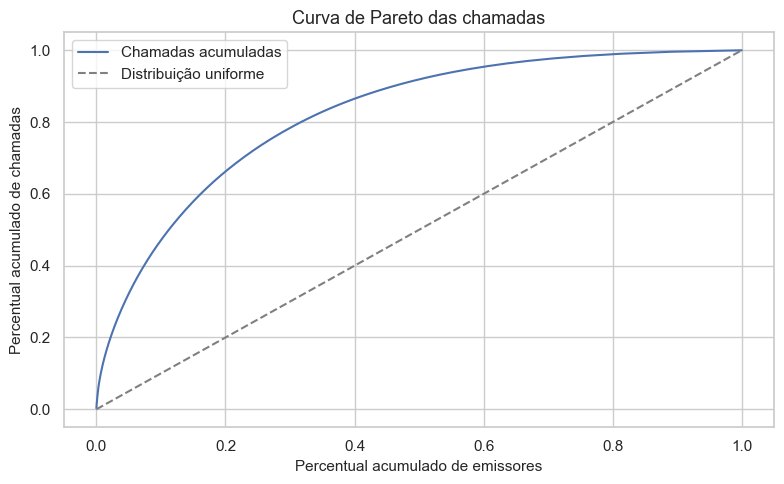

Top 1% dos emissores: 12.6% das chamadas
Top 5% dos emissores: 32.2% das chamadas
Top 10% dos emissores: 47.1% das chamadas
Top 20% dos emissores: 66.2% das chamadas


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(pareto['pct_emissores'], pareto['pct_chamadas_acum'], label='Chamadas acumuladas')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Distribuição uniforme')
plt.title('Curva de Pareto das chamadas')
plt.xlabel('Percentual acumulado de emissores')
plt.ylabel('Percentual acumulado de chamadas')
plt.legend()
plt.tight_layout()
plt.show()

for corte in [0.01, 0.05, 0.10, 0.20]:
    n = max(1, int(np.ceil(corte * len(pareto))))
    pct = pareto.loc[:n-1, 'total_calls_make'].sum() / pareto['total_calls_make'].sum()
    print(f'Top {corte:.0%} dos emissores: {pct:.1%} das chamadas')

## Preparação da tabela de arestas emissor-receptor

O parquet guarda os receptores em listas. Para analisar pares emissor-receptor, expandimos essas listas para uma tabela em que cada linha é um par.

A tabela de arestas inclui quantidade de chamadas, duração total, duração média por chamada e distância residencial em km.

In [15]:
edges_records = []

for row in campinas.itertuples(index=False):
    for receiver, q_calls, distance_km, duration_total in zip(
        row.IDs_receivers_corr,
        row.q_calls_corr,
        row.residence_distance_km_corr,
        row.calls_duration_total_corr,
    ):
        edges_records.append({
            'id_emisor': row.id_emisor,
            'id_receiver': receiver,
            'q_calls': q_calls,
            'residence_distance_km': distance_km,
            'calls_duration_total': duration_total,
        })

edges = pd.DataFrame(edges_records)
edges['avg_duration_per_call'] = edges['calls_duration_total'] / edges['q_calls'].replace(0, np.nan)
edges.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call
0,40E078FF843A5C75DCBB0C4F7A16F631,F2EB3D83BD88218C80006292B341539B,3,10.007533,2.70,0.900000
1,E251FECC98A8A1A6A669F4A96E5E83FD,37EDC910464F29BEB60588CE5A3CE0D4,18,5.480985,139.54,7.752222
2,89DCFE25604A02CB8B80725D4AA896C6,8DBF6A18EEB743B322CB639529E90198,1,0.000000,2.45,2.450000
3,1DEF0A07C69528F86FC5F9540511BD10,605AF7D72A6CE93EA7BB0BDB21ACE525,32,0.000000,45.98,1.436875
4,9749A47A3F466E787C1262E04FFDA8A1,9F34A780F9A3F3EA69867ECFCE914735,4,9.379525,1.55,0.387500


In [16]:
resumo_edges = pd.DataFrame({
    'arestas': [len(edges)],
    'emissores': [edges['id_emisor'].nunique()],
    'receptores': [edges['id_receiver'].nunique()],
    'pares_duplicados': [edges.duplicated(['id_emisor', 'id_receiver']).sum()],
    'chamadas_total_edges': [edges['q_calls'].sum()],
    'chamadas_total_emissores': [campinas['total_calls_make'].sum()],
})
resumo_edges

,arestas,emissores,receptores,pares_duplicados,chamadas_total_edges,chamadas_total_emissores
0,56139,25273,25508,0,674549,674549


## Intensidade, duração e distância das arestas

Agora cada linha é um par emissor-receptor. A coluna `q_calls` mede quantas chamadas aconteceram naquele par, `avg_duration_per_call` resume a duração média das chamadas, e `residence_distance_km` informa a distância residencial entre os dois IDs.

In [17]:
edges[['q_calls', 'calls_duration_total', 'avg_duration_per_call', 'residence_distance_km']].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
q_calls,56139.0,12.015693,26.229126,1.0,1.00,1.0000,1.000000,3.000000,11.000000,31.000000,51.000000,114.620000,879.000000
calls_duration_total,56139.0,20.950505,84.752950,0.0,0.08,0.2400,1.190000,3.970000,14.670000,45.372000,85.266000,269.574000,7339.110000
avg_duration_per_call,56139.0,1.622231,2.818882,0.0,0.07,0.1825,0.566077,0.980000,1.750000,3.252132,4.934000,11.270820,268.380000
residence_distance_km,56139.0,6.924705,8.006151,0.0,0.00,0.0000,0.000000,4.216668,10.749836,18.010459,23.225325,34.581315,57.736287


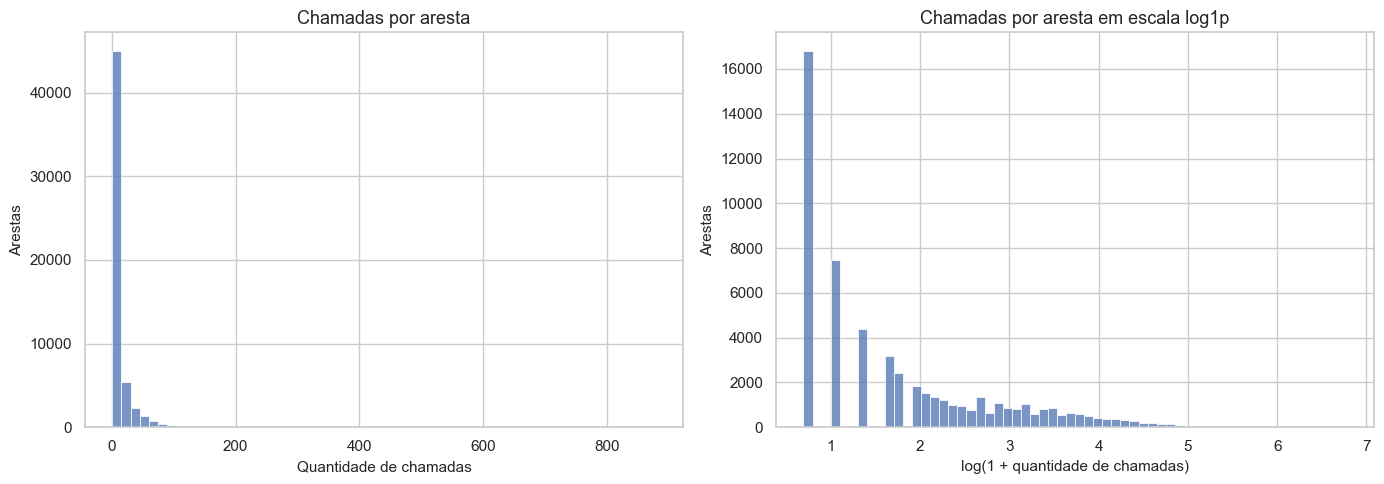

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=edges, x='q_calls', bins=60, ax=axes[0])
axes[0].set_title('Chamadas por aresta')
axes[0].set_xlabel('Quantidade de chamadas')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['q_calls']), bins=60, ax=axes[1], log_scale=(False, False))
axes[1].set_title('Chamadas por aresta em escala log1p')
axes[1].set_xlabel('log(1 + quantidade de chamadas)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

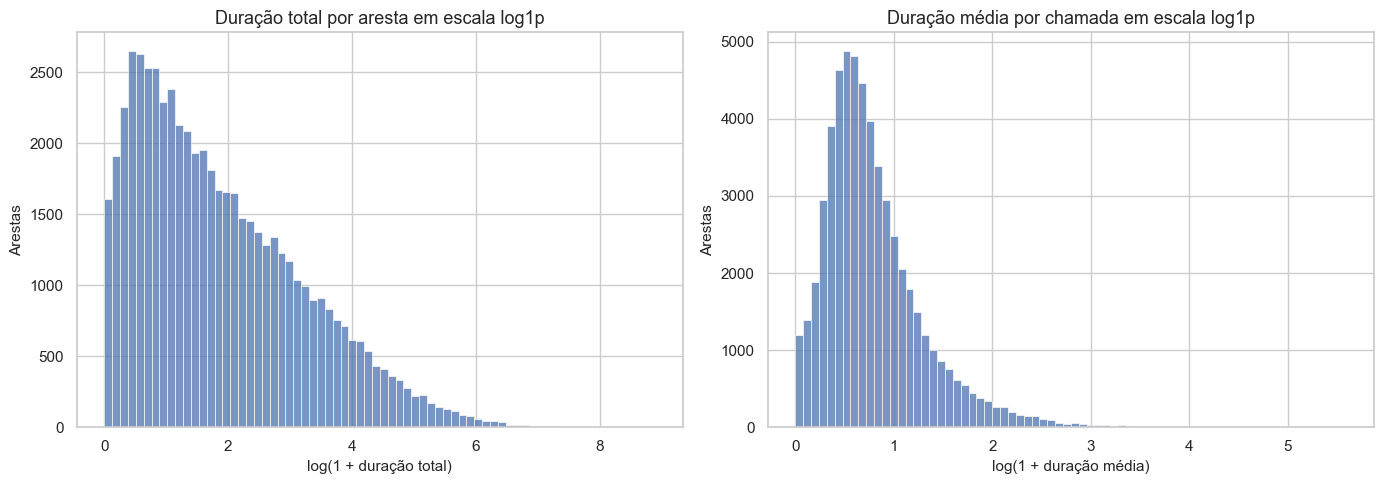

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(x=np.log1p(edges['calls_duration_total']), bins=70, ax=axes[0])
axes[0].set_title('Duração total por aresta em escala log1p')
axes[0].set_xlabel('log(1 + duração total)')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['avg_duration_per_call']), bins=70, ax=axes[1])
axes[1].set_title('Duração média por chamada em escala log1p')
axes[1].set_xlabel('log(1 + duração média)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

## Distância residencial das arestas

Esta parte olha somente para a distância que já veio no parquet. A ideia é verificar se as arestas se concentram em distâncias curtas ou se existem muitos pares distantes.

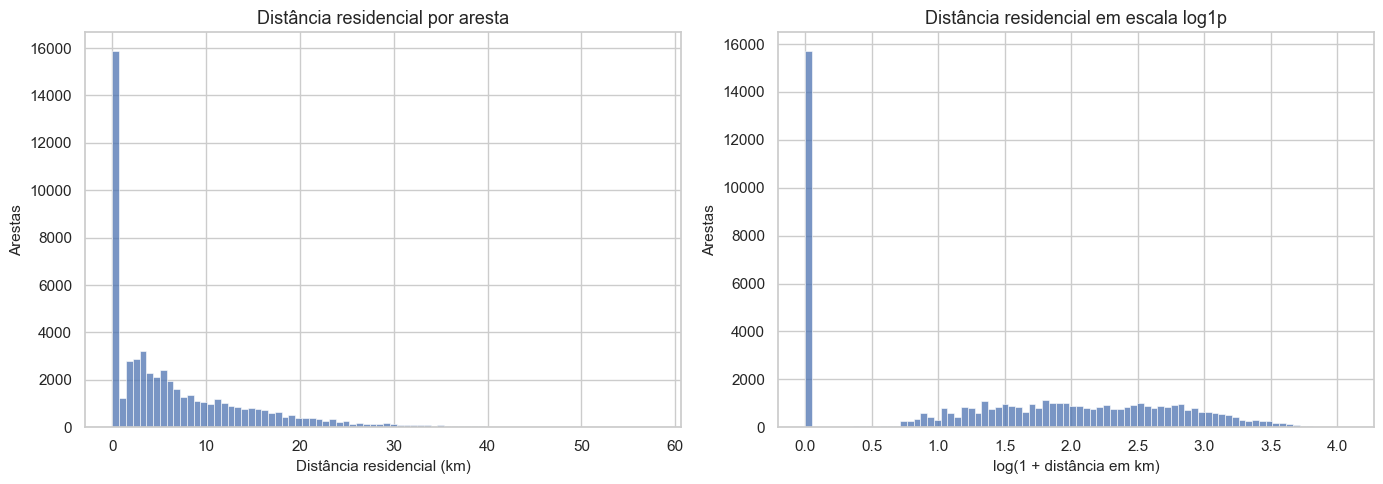

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=edges, x='residence_distance_km', bins=80, ax=axes[0])
axes[0].set_title('Distância residencial por aresta')
axes[0].set_xlabel('Distância residencial (km)')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['residence_distance_km']), bins=80, ax=axes[1])
axes[1].set_title('Distância residencial em escala log1p')
axes[1].set_xlabel('log(1 + distância em km)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

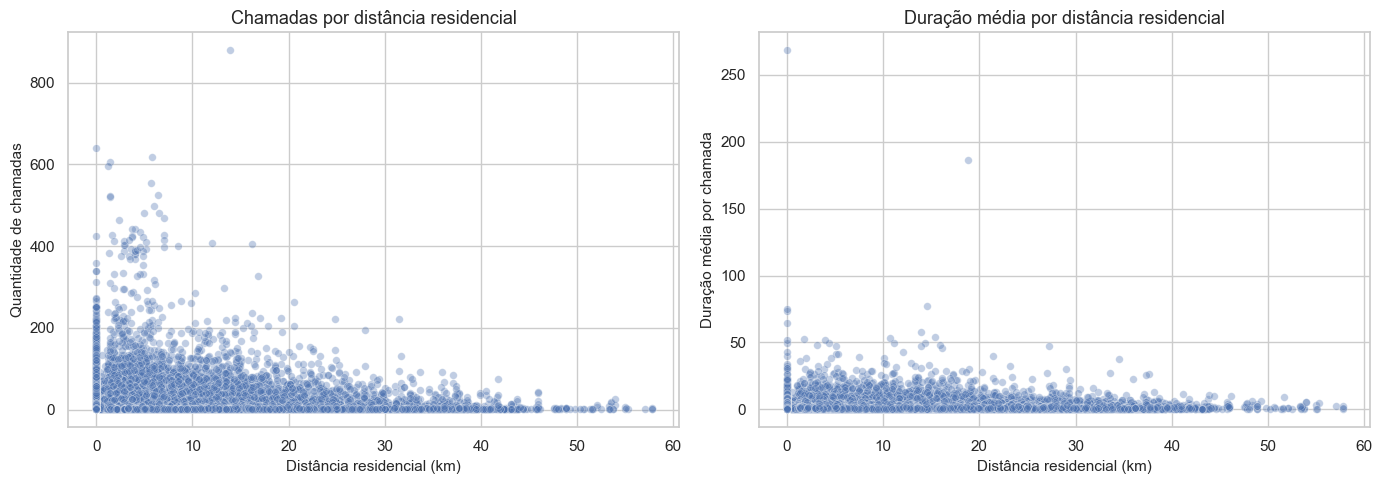

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=edges, x='residence_distance_km', y='q_calls', alpha=0.35, s=30, ax=axes[0])
axes[0].set_title('Chamadas por distância residencial')
axes[0].set_xlabel('Distância residencial (km)')
axes[0].set_ylabel('Quantidade de chamadas')

sns.scatterplot(data=edges, x='residence_distance_km', y='avg_duration_per_call', alpha=0.35, s=30, ax=axes[1])
axes[1].set_title('Duração média por distância residencial')
axes[1].set_xlabel('Distância residencial (km)')
axes[1].set_ylabel('Duração média por chamada')

plt.tight_layout()
plt.show()

In [22]:
edges['residence_distance_km'].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])

count    56139.000000
mean         6.924705
std          8.006151
min          0.000000
1%           0.000000
5%           0.000000
25%          0.000000
50%          4.216668
75%         10.749836
90%         18.010459
95%         23.225325
99%         34.581315
max         57.736287
Name: residence_distance_km, dtype: float64

In [23]:
bins_distancia = [-np.inf, 1, 3, 5, 7, 9, 11, np.inf]
labels_distancia = ['<=1', '1-3', '3-5', '5-7', '7-9', '9-11',  '>11']

edges['faixa_distancia_km'] = pd.cut(
    edges['residence_distance_km'],
    bins=bins_distancia,
    labels=labels_distancia,
)

resumo_distancia = edges.groupby('faixa_distancia_km', observed=False).agg(
    arestas=('id_receiver', 'size'),
    chamadas=('q_calls', 'sum'),
    duracao_total=('calls_duration_total', 'sum'),
    chamadas_mediana=('q_calls', 'median'),
    duracao_media_chamada=('avg_duration_per_call', 'mean'),
).reset_index()
resumo_distancia['pct_arestas'] = resumo_distancia['arestas'] / resumo_distancia['arestas'].sum()
resumo_distancia['pct_chamadas'] = resumo_distancia['chamadas'] / resumo_distancia['chamadas'].sum()
resumo_distancia

,faixa_distancia_km,arestas,chamadas,duracao_total,chamadas_mediana,duracao_media_chamada,pct_arestas,pct_chamadas
0,<=1,16009,237117,334112.15,6.0,1.285795,0.285167,0.351519
1,1-3,7586,103330,175803.54,4.0,1.592087,0.135129,0.153184
2,3-5,6733,86865,140819.35,3.0,1.652475,0.119934,0.128775
3,5-7,5702,68123,131347.89,3.0,1.768621,0.101569,0.100990
4,7-9,3603,36737,74214.97,3.0,1.820431,0.064180,0.054462
5,9-11,2924,28307,72747.18,2.0,1.917944,0.052085,0.041964
6,>11,13582,114070,247095.30,2.0,1.842931,0.241935,0.169106


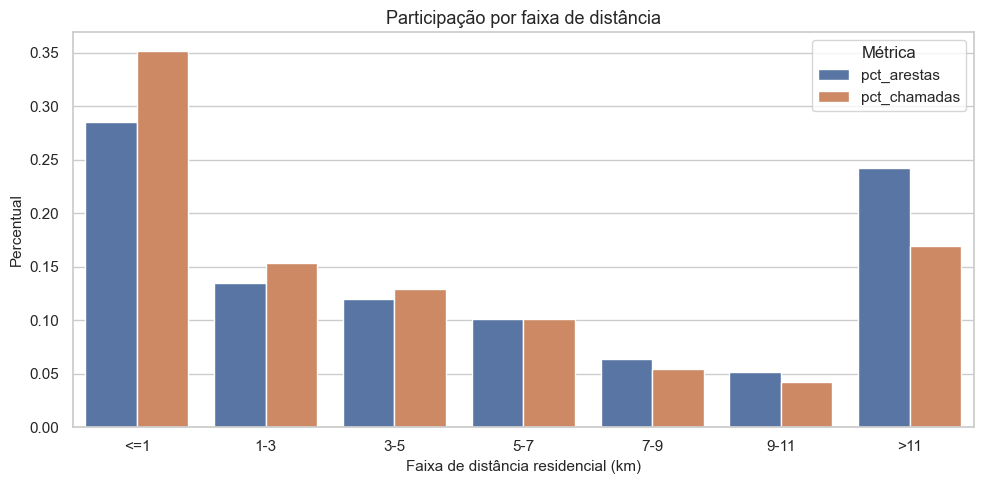

In [24]:
dist_plot = resumo_distancia.melt(
    id_vars='faixa_distancia_km',
    value_vars=['pct_arestas', 'pct_chamadas'],
    var_name='metrica',
    value_name='percentual',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=dist_plot, x='faixa_distancia_km', y='percentual', hue='metrica')
plt.title('Participação por faixa de distância')
plt.xlabel('Faixa de distância residencial (km)')
plt.ylabel('Percentual')
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

## CCDF das chamadas por aresta

A CCDF mostra a proporção de arestas que têm pelo menos `x` chamadas. Ela é útil para enxergar a cauda da distribuição: poucos pares podem concentrar muitas chamadas, mesmo que a maioria dos pares tenha baixo volume.

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


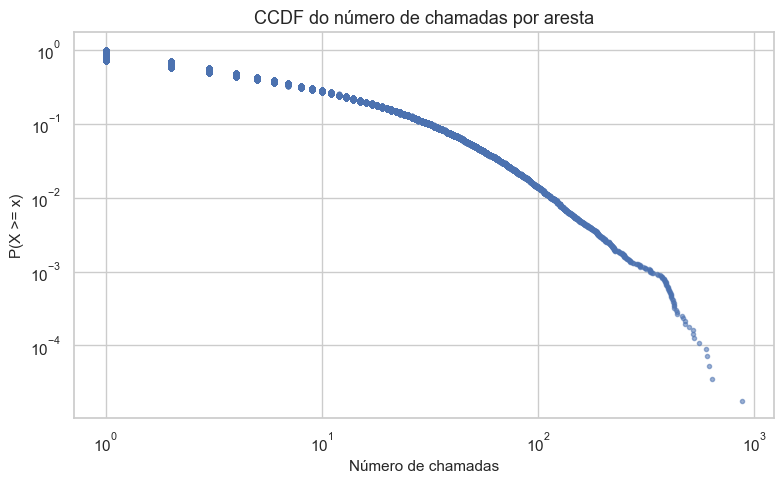

In [25]:
x = np.sort(edges['q_calls'].to_numpy())
y = 1.0 - np.arange(len(x)) / len(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='.', linestyle='none', alpha=0.55)
plt.xscale('log')
plt.yscale('log')
plt.title('CCDF do número de chamadas por aresta')
plt.xlabel('Número de chamadas')
plt.ylabel('P(X >= x)')
plt.tight_layout()
plt.show()

## Pares emissor-receptor mais fortes

Esta é uma análise adicional simples: listar os pares com mais chamadas. Ela ajuda a verificar se existem relações muito intensas que podem influenciar médias e totais.

In [26]:
top_arestas = edges.sort_values('q_calls', ascending=False)
top_arestas.head(15)

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,faixa_distancia_km
41275,62C705AD6A69DA254A33F3A9B9952CE6,180A9302C70470332BC0E806DC455E2B,879,13.862195,4458.59,5.072344,>11
32570,CD2236EC3D5CB1FB25A84482E0769FEA,8F270304A9BD71420CA9CF039CFE29CF,639,0.000000,1560.18,2.441596,<=1
39599,4C61C0D20FBDF8C4F52636A09A6A6EFC,77F895843B03460FAD4AFBAE5814C767,619,5.819760,973.24,1.572278,5-7
1658,679C626660F0E5E3875FD2C339656038,E1CE80141830DF7BD5D1159FD3101597,607,1.390454,374.12,0.616343,1-3
32478,DFDB7975D61C6EF7A015A03F2280756D,848A490436F7A84F9825681F43316CCF,595,1.251165,828.63,1.392655,1-3
32294,049D381986B054C84BC8DB854672CBBE,7A0F2CEBBD816DB473BDB6F873CB3D79,555,5.669762,483.75,0.871622,5-7
6658,8C27F54CD3363CDA671B3FF90B85AE00,9D7497DD5206368FD7157C78B7680006,526,6.473140,1137.05,2.161692,5-7
53563,46D13D45048C8F41C9A6F1FF1A4DF9E3,6055E4F8391EB79CFAFEC56349161FC5,523,1.395326,488.49,0.934015,1-3
14219,6055E4F8391EB79CFAFEC56349161FC5,46D13D45048C8F41C9A6F1FF1A4DF9E3,520,1.395326,531.28,1.021692,1-3
7207,604310C120387BB36ADC8AF7B47F6791,2EB46FE449F8F417E9A5854C7FD58920,498,5.971676,757.86,1.521807,5-7


## Concentração de contatos por emissor

Esta análise mede quanto cada emissor depende do seu principal receptor. O `share_top_receptor` é a proporção das chamadas do emissor que foram para o receptor mais chamado.

Valores perto de 1 indicam comunicação muito concentrada. Valores menores indicam chamadas mais distribuídas entre diferentes contatos.

In [27]:
concentracao = edges.groupby('id_emisor').agg(
    chamadas_total=('q_calls', 'sum'),
    receptores=('id_receiver', 'nunique'),
    maior_volume_receptor=('q_calls', 'max'),
).reset_index()
concentracao['share_top_receptor'] = concentracao['maior_volume_receptor'] / concentracao['chamadas_total']
concentracao['chamadas_por_receptor'] = concentracao['chamadas_total'] / concentracao['receptores']

concentracao.sort_values(['share_top_receptor', 'chamadas_total'], ascending=[False, False]).head(15)

,id_emisor,chamadas_total,receptores,maior_volume_receptor,share_top_receptor,chamadas_por_receptor
7593,4C61C0D20FBDF8C4F52636A09A6A6EFC,619,1,619,1.0,619.0
22086,DFDB7975D61C6EF7A015A03F2280756D,595,1,595,1.0,595.0
13857,8C27F54CD3363CDA671B3FF90B85AE00,526,1,526,1.0,526.0
23251,EBF56A1F3791D253A9B69E5BEDD8BD69,406,1,406,1.0,406.0
11223,720631EAEB30C2501C6E6EE00DE2ACF4,297,1,297,1.0,297.0
15090,98E7424AA7AF5413D5B11DB2744C2A9E,285,1,285,1.0,285.0
1390,0DD08C6A20A66B39D295BC2DE14E23AA,270,1,270,1.0,270.0
1385,0DC8BAE2E066D7DC7E19DF0158C1DEEA,263,1,263,1.0,263.0
19914,C9E3DF76BD44FF333D937B124C27272A,259,1,259,1.0,259.0
20585,D056BAC4DCB78BBD03B3A8320696F975,257,1,257,1.0,257.0


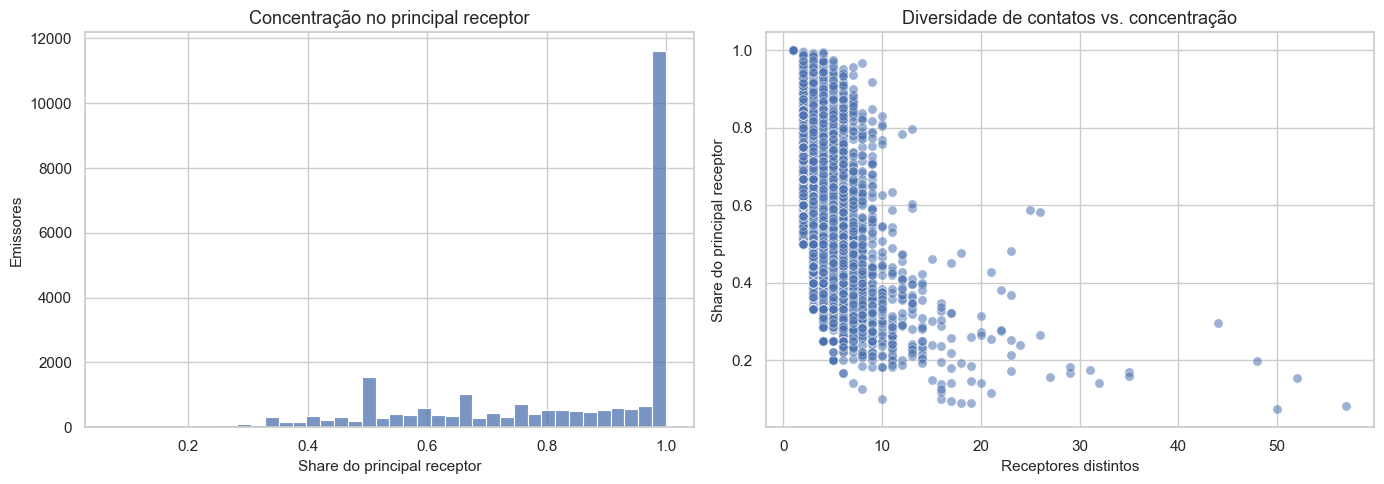

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=concentracao, x='share_top_receptor', bins=40, ax=axes[0])
axes[0].set_title('Concentração no principal receptor')
axes[0].set_xlabel('Share do principal receptor')
axes[0].set_ylabel('Emissores')

sns.scatterplot(data=concentracao, x='receptores', y='share_top_receptor', alpha=0.55, s=45, ax=axes[1])
axes[1].set_title('Diversidade de contatos vs. concentração')
axes[1].set_xlabel('Receptores distintos')
axes[1].set_ylabel('Share do principal receptor')

plt.tight_layout()
plt.show()

## Classificação simples de emissores

Para facilitar a leitura, criamos faixas simples de atividade com base no número total de chamadas. Esta classificação não é um modelo; é apenas um resumo exploratório para entender a composição da base.

In [29]:
bins_chamadas = [-np.inf, 1, 5, 10, 25, 50, 100, np.inf]
labels_chamadas = ['1', '2-5', '6-10', '11-25', '26-50', '51-100', '>100']

campinas['faixa_total_chamadas'] = pd.cut(
    campinas['total_calls_make'],
    bins=bins_chamadas,
    labels=labels_chamadas,
)

faixa_emissores = campinas.groupby('faixa_total_chamadas', observed=False).agg(
    emissores=('id_emisor', 'size'),
    chamadas=('total_calls_make', 'sum'),
    receptores_mediana=('unique_receivers', 'median'),
).reset_index()
faixa_emissores['pct_emissores'] = faixa_emissores['emissores'] / faixa_emissores['emissores'].sum()
faixa_emissores['pct_chamadas'] = faixa_emissores['chamadas'] / faixa_emissores['chamadas'].sum()
faixa_emissores

,faixa_total_chamadas,emissores,chamadas,receptores_mediana,pct_emissores,pct_chamadas
0,1,2946,2946,1.0,0.116567,0.004367
1,2-5,5642,18111,1.0,0.223242,0.026849
2,6-10,3458,26996,2.0,0.136826,0.040021
3,11-25,5430,92219,2.0,0.214854,0.136712
4,26-50,4011,144175,2.0,0.158707,0.213735
5,51-100,2597,180458,3.0,0.102758,0.267524
6,>100,1189,209644,3.0,0.047046,0.310791


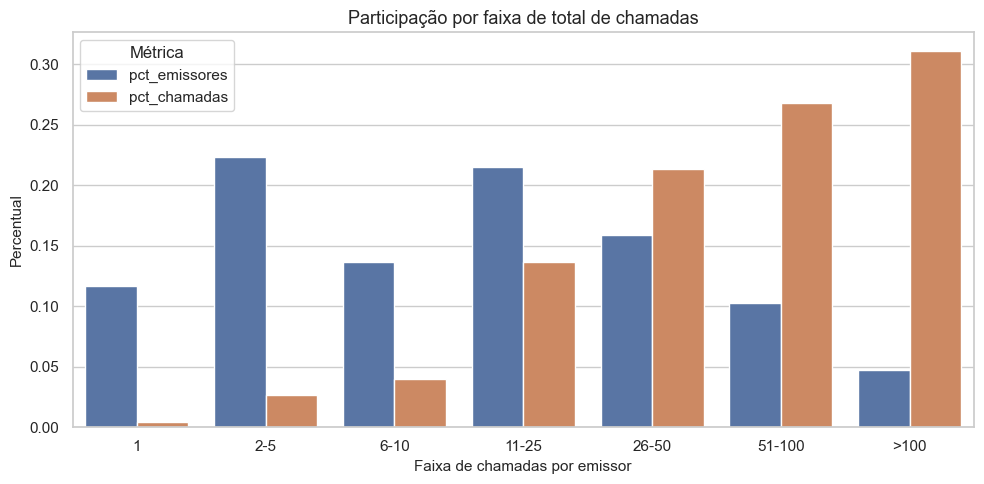

In [30]:
faixa_plot = faixa_emissores.melt(
    id_vars='faixa_total_chamadas',
    value_vars=['pct_emissores', 'pct_chamadas'],
    var_name='metrica',
    value_name='percentual',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=faixa_plot, x='faixa_total_chamadas', y='percentual', hue='metrica')
plt.title('Participação por faixa de total de chamadas')
plt.xlabel('Faixa de chamadas por emissor')
plt.ylabel('Percentual')
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

## Leituras iniciais

- A base está agregada por emissor; por isso, a primeira parte da EDA olha para comportamento individual dos emissores.
- A expansão para arestas é essencial para analisar pares emissor-receptor de forma simples.
- O total de chamadas e a quantidade de chamadas por aresta parecem exigir leitura por mediana, percentis, Pareto e CCDF, porque poucos casos podem concentrar muito volume.
- A distância residencial permite verificar se a comunicação se concentra em pares próximos ou se há volume relevante em pares mais distantes.
- `chamadas_por_receptor` e `share_top_receptor` ajudam a separar emissores com comunicação distribuída daqueles com comunicação concentrada.
- Esta versão usa apenas informações presentes no parquet; nenhum cruzamento externo é feito.

# Exportação da tabela de emissores - receptores

In [31]:
edges.drop(columns=['faixa_distancia_km'], inplace=True)
out_path = DATA_DIR / 'edges.csv'
edges.to_csv(out_path, index=False)
print(f'Saved edges ({len(edges):,} rows) to {out_path}')

Saved edges (56,139 rows) to dados\edges.csv


In [32]:
edges.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call
0,40E078FF843A5C75DCBB0C4F7A16F631,F2EB3D83BD88218C80006292B341539B,3,10.007533,2.70,0.900000
1,E251FECC98A8A1A6A669F4A96E5E83FD,37EDC910464F29BEB60588CE5A3CE0D4,18,5.480985,139.54,7.752222
2,89DCFE25604A02CB8B80725D4AA896C6,8DBF6A18EEB743B322CB639529E90198,1,0.000000,2.45,2.450000
3,1DEF0A07C69528F86FC5F9540511BD10,605AF7D72A6CE93EA7BB0BDB21ACE525,32,0.000000,45.98,1.436875
4,9749A47A3F466E787C1262E04FFDA8A1,9F34A780F9A3F3EA69867ECFCE914735,4,9.379525,1.55,0.387500


In [33]:
edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 56139 entries, 0 to 56138
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_emisor              56139 non-null  str    
 1   id_receiver            56139 non-null  str    
 2   q_calls                56139 non-null  int64  
 3   residence_distance_km  56139 non-null  float64
 4   calls_duration_total   56139 non-null  float64
 5   avg_duration_per_call  56139 non-null  float64
dtypes: float64(3), int64(1), str(2)
memory usage: 6.0 MB


# Agregação das informações de localização

Primeiro, devemos entender o que os dados da tabela `residencias.csv` significam:

- `ID`: é o mesmo identificador utilizado na tabela anterior. Cada pessoa possui um ID único.
- `residence_geometry`: representa a localização geográfica da residência no formato `Well-Known Binary (WKB)`. Posteriormente, será necessário converter esses dados para coordenadas utilizáveis, como latitude e longitude.
- `residence_city`: cidade de residência do usuário.
- `residence_quintile_state`: indica o quintil socioeconômico do usuário dentro do estado.
- `residence_quintile_nation`: indica o quintil socioeconômico do usuário em relação ao país inteiro.

Os quintis dividem a população em cinco grupos socioeconômicos:

| Quintil | Significado            |
|----------|-------------------------|
| q1       | 20% mais pobres         |
| q2       | Faixa intermediária baixa |
| q3       | Faixa intermediária     |
| q4       | Faixa intermediária alta |
| q5       | 20% mais ricos          |

Essas informações permitem relacionar características socioeconômicas e geográficas com os padrões de comunicação observados na rede telefônica, possibilitando análises envolvendo:
- desigualdade social;
- distribuição espacial das conexões;
- intensidade de comunicação por região;
- comportamento de diferentes grupos socioeconômicos;
- formação de comunidades e hubs na rede.

A ideia é agregar os dados da localização do emissor e receptor, e os quintis do emissor e receptor no dataframe `edges.csv`, para uma futura análise do sistema complexo que montaremos

In [34]:
residencias = pd.read_csv(RESIDENCIAS_PATH)

In [35]:
residencias.head()

,ID,residence_geometry,residence_city,residence_quintile_state,residence_quintile_nation
0,0A7BF148110B6D5AE29939017AEB843A,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
1,0FBC0A930414D2ED92B6F4B8661BB997,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
2,0BA404BCA3069A8C9FA6ABE70225A1C8,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
3,133947C1230823B09FA68416DED5E090,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
4,0FADED95A81CAC14BD136CAAF597E425,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1


In [ ]:
# Selecionamos da base de residencias apenas as colunas de localizacao e quintil.
# A juncao completa em `edges` nao e feita aqui: a tabela final por antena e
# construida adiante, a partir dos IDs com residencia conhecida.
res = residencias[[
    "ID",
    "residence_geometry",
    "residence_city",
    "residence_quintile_state",
    "residence_quintile_nation",
]].copy()

# Padroniza os IDs como string para casar com `edges`.
edges["id_emisor"] = edges["id_emisor"].astype(str).str.strip()
edges["id_receiver"] = edges["id_receiver"].astype(str).str.strip()
res["ID"] = res["ID"].astype(str).str.strip()

res.head()

Parece que alguns emissores e rececptores não existem, vamos verificar isso

## Verificação dos nós sem informações de localização

In [38]:
# 1. Quantos emissores não existem em residencias?
ids_res = set(res["ID"])

faltando_emissor = ~edges["id_emisor"].isin(ids_res)

print("Emissores sem residência:", faltando_emissor.sum())
print("Total de emissores:", len(edges))
print("Percentual:", 100 * faltando_emissor.mean(), "%")

Emissores sem residência: 4400
Total de emissores: 56139
Percentual: 7.8376885943818015 %


In [39]:
# 2. Quantos receptores não existem?
faltando_receptor = ~edges["id_receiver"].isin(ids_res)

print("Receptores sem residência:", faltando_receptor.sum())
print("Total de receptores:", len(edges))
print("Percentual:", 100 * faltando_receptor.mean(), "%")

Receptores sem residência: 4364
Total de receptores: 56139
Percentual: 7.77356205133686 %


In [40]:
# 3. Quais IDs estão faltando?
ids_emissor_faltando = set(
    edges.loc[faltando_emissor, "id_emisor"]
)

ids_receptor_faltando = set(
    edges.loc[faltando_receptor, "id_receiver"]
)

print("Emissores únicos faltando:", len(ids_emissor_faltando))
print("Receptores únicos faltando:", len(ids_receptor_faltando))

Emissores únicos faltando: 1994
Receptores únicos faltando: 1991


In [41]:
# Mostrar alguns exemplos:
list(ids_emissor_faltando)[:20]

['8930BEEC8A900F7046F585EFB0512AC6',
 '64F918DD40F37BF1BD6007292DABDAC0',
 '9F8313CDEDB1A40C3EF70618ED603602',
 'E385EAFF05D0F2C5F3F5BC08E9CBE42D',
 '2D697644C911707FB9B141FFA2C99191',
 'F09A8529BF3324D0C4EC1216E057E7A5',
 'E6E36869B32DEFA9F64BF12AE74C926F',
 'B0D4ED1EFC12EA04BE1FCE92596F4C86',
 'D7180708B921C659DF2ED47EC4B7DB80',
 '0536953FDADBE1AFC25EEB6DCAED5963',
 'D8FACC84071A8C4E5BE5BF9F52BB19C2',
 'F12129D23F7021A5485F87152D78F6C2',
 'D4726063E0879E47ECBDE7194DEF9EA8',
 '454CEC34169A52EF27976376E6DACED7',
 '8E0DC7783F0F06085ABEC3C7CA5E8565',
 '4BFDFAFE2D8D881E900563AD5AA75CF8',
 '5A0DBE95A07974732649442F99DD9D4B',
 '37F79CD69C3D391294DD416445B3CAF4',
 'B7B41BD05FD1B37E0B2AEC2C5F56B6F4',
 '30335BA47DA45FBD63DFE4355F407897']

In [43]:
# 5. Verificar se o problema é tipo de dado
print(edges["id_emisor"].dtype)
print(res["ID"].dtype)

str
str


In [ ]:
# IDs presentes na rede mas ausentes em residencias.csv
ids_edges = set(edges["id_emisor"]) | set(edges["id_receiver"])
ids_res = set(res["ID"])
ids_sem_res = ids_edges - ids_res

print(f"Nos sem residencia: {len(ids_sem_res)}")

In [45]:
grau_emissor = edges["id_emisor"].value_counts()
grau_receptor = edges["id_receiver"].value_counts()

grau_total = grau_emissor.add(
    grau_receptor,
    fill_value=0
)

In [46]:
graus_faltantes = grau_total.reindex(list(ids_sem_res))

print(graus_faltantes.describe())

count    2183.000000
mean        4.014659
std         3.097524
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        39.000000
Name: count, dtype: float64


In [47]:
graus_faltantes.sort_values(
    ascending=False
).head(20)

id_emisor
BE155E584291F77B7F400F00188D2EB0    39.0
BE63327412A57EA7F36F54EB29FE91C0    34.0
6EB88D3B92A3F966C8D3C73A9FF5A880    27.0
2D86F11F85567256D0113869ECE26A5F    25.0
CE5BBB5BFC1A37B4E386F4B62CF5F45A    23.0
F3C95646D9C789CCB7E3155AB4466578    23.0
4BFDFAFE2D8D881E900563AD5AA75CF8    21.0
53A0DF2C53A0A117D531E302B10AC331    19.0
0BB87CF37EEA1AF22B3B3665F578FD90    18.0
5380D83E8287B07D1A1B402421A67371    18.0
3EFB4BBDBEC4FD5C1DACB63F380E3A10    18.0
3B088F3E6A9977E27BF423D66B7A20D8    17.0
98F27D678237D095B11F7AFF7C2882D3    17.0
F12129D23F7021A5485F87152D78F6C2    17.0
B550684725DD51271083F377DA824682    17.0
EE6D8F46D9BDFBB10432825FB047BBC8    17.0
78F203F3E4C37B421026E79544BA32A0    16.0
E69D97BF5587D5B8C9DAB7D0289B1ABB    16.0
FA7340CFD7E1E2A7664B4F88313EB5E4    15.0
22CA3C92C1805C06362BBD23E7C0AB43    15.0
Name: count, dtype: float64

In [48]:
grau_total.describe()

count    27938.000000
mean         4.018827
std          3.672035
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        105.000000
Name: count, dtype: float64

### Conclusão sobre os nós sem localização

Cerca de **7,8% dos nós** da rede não têm residência cadastrada em `residencias.csv`. Esses nós têm
grau baixo (mediana 3), ou seja, são usuários periféricos, e não hubs. Por isso eles são removidos
ao construir a tabela final por antena (a seguir): mantemos apenas arestas em que emissor **e**
receptor têm residência conhecida, garantindo que toda a rede espacial tenha coordenadas.

## Construção das tabelas de antena e usuário

A partir dos IDs com residência conhecida, criamos: (1) `edges_antenna`, com as arestas filtradas e
o identificador de antena de cada extremo; e (2) `antennas`, a tabela de antenas residenciais
distintas com cidade e quintis. Essas duas tabelas, restritas a Campinas, alimentam o notebook de
rede complexa.

In [4]:
import pandas as pd

from pathlib import Path



if "DATA_DIR" not in globals():

    DATA_DIR = Path("./dados")



if "edges" not in globals():

    edges = pd.read_csv(DATA_DIR / "edges.csv")



if "res" not in globals():

    residencias = pd.read_csv(DATA_DIR / "residencias.csv")

    res = residencias[[

        "ID",

        "residence_geometry",

        "residence_city",

        "residence_quintile_state",

        "residence_quintile_nation",

    ]].copy()



edges["id_emisor"] = edges["id_emisor"].astype(str).str.strip()

edges["id_receiver"] = edges["id_receiver"].astype(str).str.strip()

res["ID"] = res["ID"].astype(str).str.strip()



ids_res = set(res["ID"])



edges_antenna = edges[

    edges["id_emisor"].isin(ids_res)

    & edges["id_receiver"].isin(ids_res)

].copy()

In [5]:
res_antenna_base = res[[

    "ID",

    "residence_geometry",

    "residence_city",

    "residence_quintile_state",

    "residence_quintile_nation",

]].copy()



# Cada geometria de residência representa uma antena.

antenna_key = (

    res_antenna_base["residence_geometry"]

    .astype("string")

    .fillna("<NA>")

)

res_antenna_base["antenna_id"] = pd.factorize(

    antenna_key,

    sort=True

)[0] + 1



antennas = (

    res_antenna_base[[

        "antenna_id",

        "residence_geometry",

        "residence_city",

        "residence_quintile_state",

        "residence_quintile_nation",

    ]]

    .drop_duplicates(subset=["antenna_id"])

    .sort_values("antenna_id")

    .reset_index(drop=True)

)



user_to_antenna = res_antenna_base.set_index("ID")["antenna_id"]



edges_antenna["emissor_antenna_id"] = (

    edges_antenna["id_emisor"]

    .map(user_to_antenna)

    .astype("Int64")

)



edges_antenna["receptor_antenna_id"] = (

    edges_antenna["id_receiver"]

    .map(user_to_antenna)

    .astype("Int64")

)

In [6]:
edges_antenna[["emissor_antenna_id", "receptor_antenna_id"]].isna().sum()

emissor_antenna_id     0
receptor_antenna_id    0
dtype: int64

In [7]:
print(edges_antenna.shape)

print(antennas.shape)



edges_antenna.head()

(48947, 8)
(8530, 5)


,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,emissor_antenna_id,receptor_antenna_id
1,E251FECC98A8A1A6A669F4A96E5E83FD,37EDC910464F29BEB60588CE5A3CE0D4,18,5.480985,139.54,7.752222,494,5813
2,89DCFE25604A02CB8B80725D4AA896C6,8DBF6A18EEB743B322CB639529E90198,1,0.000000,2.45,2.450000,7924,7924
3,1DEF0A07C69528F86FC5F9540511BD10,605AF7D72A6CE93EA7BB0BDB21ACE525,32,0.000000,45.98,1.436875,580,580
4,9749A47A3F466E787C1262E04FFDA8A1,9F34A780F9A3F3EA69867ECFCE914735,4,9.379525,1.55,0.387500,2546,7790
5,D4A62AA301336DBC49DA15BE818665A1,691BAC0D4F95B0D85118C79226F42B99,39,0.000000,33.43,0.857179,7096,7096


In [9]:
antennas.head()

,antenna_id,residence_geometry,residence_city,residence_quintile_state,residence_quintile_nation
0,1,"b""\x01\x01\x00\x00\x00 $\x0b\x98\xc0\x99I\xc0\...",Caxias do Sul,q5,q5
1,2,"b""\x01\x01\x00\x00\x00!\xb0rh\x91\xddA\xc0}'f\...",Maceió,q5,q5
2,3,"b""\x01\x01\x00\x00\x00#J{\x83/\x98I\xc0\x16Mg'...",Caxias do Sul,q2,q3
3,4,"b""\x01\x01\x00\x00\x00#\x84G\x1bG\x90A\xc0|'f\...",Natal,q4,q3
4,5,"b""\x01\x01\x00\x00\x00#\xee\xb1\xf4\xa1'H\xc0\...",Belém,q1,q1


In [13]:
antennas = antennas[antennas['residence_city']=='Campinas']

In [18]:
antennas.shape

(145, 5)

In [21]:
edges_out_path = DATA_DIR / 'edges_antenna.parquet'

antennas_out_path = DATA_DIR / 'antennas.parquet'



edges_antenna.to_parquet(

    edges_out_path,

    index=True

)



antennas.to_parquet(

    antennas_out_path,

    index=False

)



print(f'Arestas com antenna_id salvas em: {edges_out_path}')

print(f'Tabela de antenas salva em: {antennas_out_path}')

Arestas com antenna_id salvas em: dados\edges_antenna.parquet
Tabela de antenas salva em: dados\antennas.parquet
